In [1]:
from pathlib import Path
DIR_OUTPUT = Path("./output")
DIR_INPUT = Path("./data")
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)
DIR_INPUT.mkdir(parents=True, exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

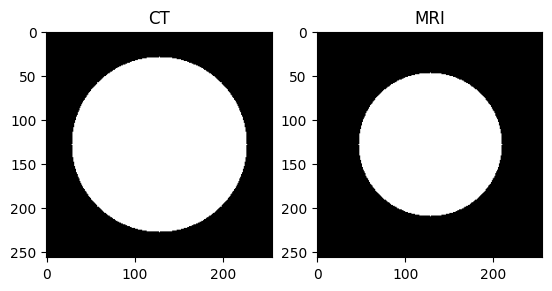

In [3]:
ct = cv2.imread(DIR_INPUT / "CT_slice_001.png", cv2.IMREAD_GRAYSCALE)
mri = cv2.imread(DIR_INPUT / "MRI_slice_001.png", cv2.IMREAD_GRAYSCALE)

plt.subplot(1,2,1)
plt.imshow(ct, cmap="gray")
plt.title("CT")

plt.subplot(1,2,2)
plt.imshow(mri, cmap="gray")
plt.title("MRI")
plt.show()

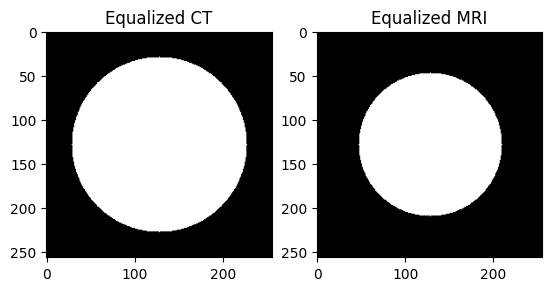

True

In [5]:
equalized_ct = cv2.equalizeHist(ct)
equalized_mri = cv2.equalizeHist(mri)

plt.subplot(1, 2, 1)
plt.imshow(equalized_ct, cmap="gray")
plt.title("Equalized CT")

plt.subplot(1, 2, 2)
plt.imshow(equalized_mri, cmap="gray")
plt.title("Equalized MRI")
plt.show()

cv2.imwrite(DIR_OUTPUT / "equalized_ct.png", equalized_ct)
cv2.imwrite(DIR_OUTPUT / "equalized_mri.png", equalized_mri)

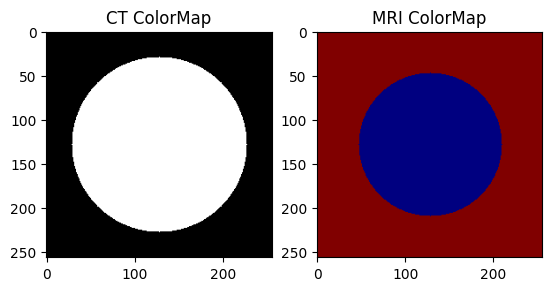

True

In [7]:
ct_color = cv2.applyColorMap(equalized_ct, cv2.COLORMAP_BONE)
mri_color = cv2.applyColorMap(equalized_mri, cv2.COLORMAP_JET)

plt.subplot(1, 2, 1)
plt.imshow(ct_color)
plt.title("CT ColorMap")

plt.subplot(1, 2, 2)
plt.imshow(mri_color)
plt.title("MRI ColorMap")
plt.show()

cv2.imwrite(DIR_OUTPUT / "ct_colormap.png", ct_color)
cv2.imwrite(DIR_OUTPUT / "mri_colormap.png", mri_color)

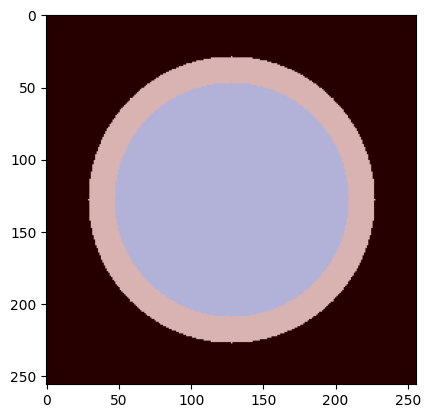

True

In [8]:
#cv2.addWeighted(src1, alpha, src2, beta, gamma)
#alpha and beta control how much each image contributes. They usually add up to 1.
#gamma is a brightness offset (use 0).

fused = cv2.addWeighted(ct_color, 0.7, mri_color, 0.3, 0) # heavier weight on CT to keep the edges sharp, MRI just adds the tissue detail on top
plt.imshow(fused)
plt.show()

cv2.imwrite(DIR_OUTPUT / "fused.png", fused)

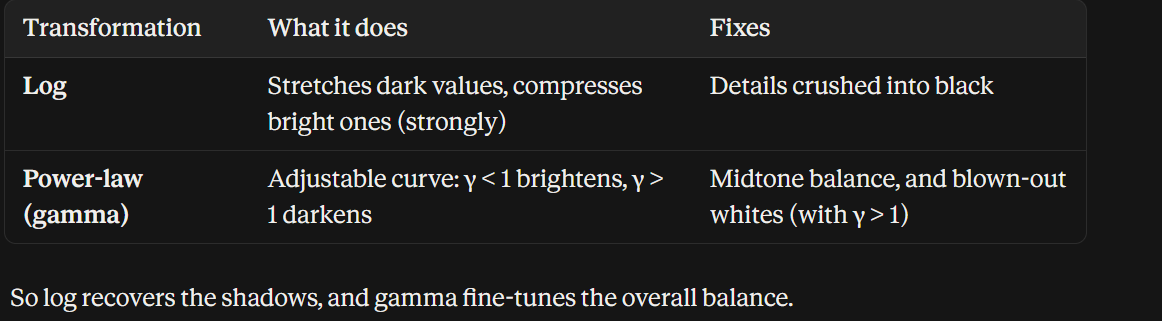

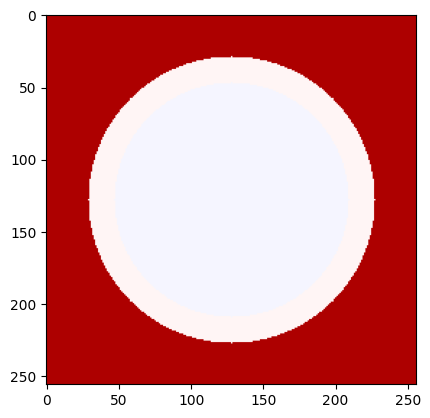

True

In [9]:
# Log:    output = c × log(1 + input)
# Gamma:  output = 255 × (input / 255) ^ γ

img = fused.astype(np.float32)
c = 255 / np.log(1+img.max())
log_fused = c * np.log(1+img)
log_fused = np.array(log_fused, dtype=np.uint8)
plt.imshow(log_fused)
plt.show()

cv2.imwrite(DIR_OUTPUT / "log_fused.png", log_fused)

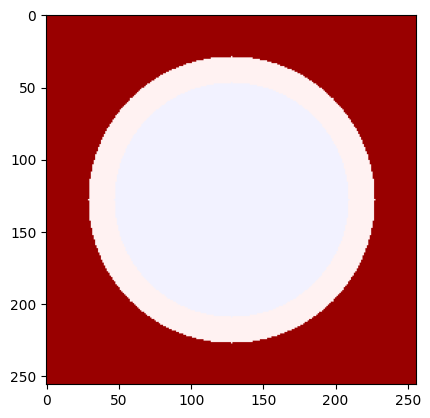

True

In [10]:
def power_law(img, gamma):
  lut = np.array([255 * (i/255) ** gamma for i in range(256)])
  lut = np.clip(lut, 0, 255).astype(np.uint8)
  return cv2.LUT(img, lut)

fused_final = power_law(log_fused, 1.3)
plt.imshow(fused_final)
plt.show()

cv2.imwrite(DIR_OUTPUT / "powerLaw_fused.png", fused_final)

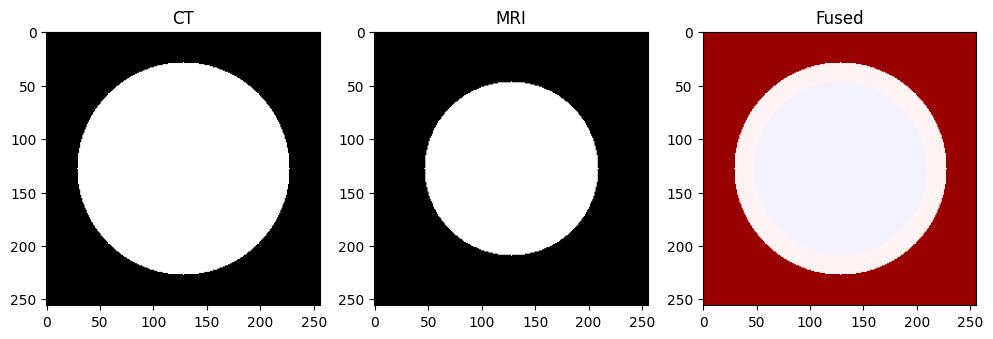

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(ct, cmap="gray")
plt.title("CT")

plt.subplot(1, 3, 2)
plt.imshow(mri, cmap="gray")
plt.title("MRI")

plt.subplot(1, 3, 3)
plt.imshow(fused_final)
plt.title("Fused")
plt.show()